# Christian Chung - BIOE242 Checkpoint 4: Production Mode

## Summary of Prior Checkpoints

| Checkpoint | Date | What was done |
|------------|------|---------------|
| Data Preparation | Mar 30 | Parsed Chaste VTU snapshots into PyG graphs; built cell contact networks; split 7/2/1 by simulation variant; triplicates; N\_MAX=300 subsampling; 8,605 graphs total |
| Model Construction | Apr 6 | PCA + UMAP + K-Means (unsupervised); MLP null baseline (topology-blind); GraphSAGE GNN (topology-aware); two tasks: binary fluid/solid and 3-class suite |
| Regularization & Tuning | Apr 13 | Sequential hyperparameter sweeps (dropout, weight decay, depth, hidden dim, LR); best-checkpoint saving; early stopping; GNN improved from 37.8% to 60.4% test accuracy on 3-class suite task |

## Best Hyperparameters (Observed from Checkpoint 3)
| Parameter | GNN | MLP |
|-----------|-----|-----|
| dropout | 0.0 | -- |
| weight decay | 1e-3 | 0.0 |
| n\_layers | 5 | -- |
| hidden | 128 | 64 |
| lr | 5e-4 | 1e-3 |
| batch size | 64 | 128 |

## Goals for the Production Mode Checkpoint:
1. **Retrain on all available data** -- fix the hyperparameters, combine train + val + test into one training set to produce the strongest possible model for deployment
2. **Confusion matrix** -- break down where the tuned model succeeds and fails per class
3. **Temporal trajectory** -- run the production GNN on every snapshot of one simulation variant in sequence; visualize how predicted class probabilities evolve over simulated time

Note: The original goal was to use Savio and the GPU cluster to help test some more hyperparameter combinations. However, given the complications around Savio and the inability to run things effectively, I will run purely on CPU (I fortunately have a gaming laptop with specs that can process this on it's own).

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import copy

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

import torch_geometric
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

import meshio

BANK    = Path(r'c:/Users/cmchu/OneDrive/Desktop/Gu Lab/BIOE242 Data/BIOE242 Data Bank Complete')
SIM_ROOT = Path(r'c:/Users/cmchu/OneDrive/Desktop/Gu Lab/BIOE242 Data/replicated_testoutput/EpithelialRheology')
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SUITE_NAMES_3 = ['Adhesion', 'DeformEnergy', 'Proliferation']
print(f'Device: {DEVICE}')
print(f'PyTorch Geometric: {torch_geometric.__version__}')

Device: cpu
PyTorch Geometric: 2.7.0


## 2. Load data

In [2]:
train_graphs = torch.load(BANK / 'train_graphs.pt', weights_only=False)
val_graphs   = torch.load(BANK / 'val_graphs.pt',   weights_only=False)
test_graphs  = torch.load(BANK / 'test_graphs.pt',  weights_only=False)
train_raw    = torch.load(BANK / 'train_graphs_raw.pt', weights_only=False)
val_raw      = torch.load(BANK / 'val_graphs_raw.pt',   weights_only=False)
test_raw     = torch.load(BANK / 'test_graphs_raw.pt',  weights_only=False)

SHAPE_IDX_THRESHOLD = 3.81

def attach_labels(norm_list, raw_list):
    for g_norm, g_raw in zip(norm_list, raw_list):
        mq = float(g_raw.x[:, 2].mean())
        g_norm.binary_label = torch.tensor([1 if mq > SHAPE_IDX_THRESHOLD else 0], dtype=torch.long)
        g_norm.suite_label  = torch.tensor([int(g_norm.y[0].item())], dtype=torch.long)

attach_labels(train_graphs, train_raw)
attach_labels(val_graphs,   val_raw)
attach_labels(test_graphs,  test_raw)

def make_suite3(graphs):
    out = []
    for g in graphs:
        s = g.suite_label.item()
        if s == 0:
            continue
        gc = g.clone()
        gc.suite_label_3 = torch.tensor([s - 1], dtype=torch.long)
        out.append(gc)
    return out

train_s3 = make_suite3(train_graphs)
val_s3   = make_suite3(val_graphs)
test_s3  = make_suite3(test_graphs)

# Production dataset: all graphs combined
all_s3 = train_s3 + val_s3 + test_s3

print(f'Train: {len(train_s3)} | Val: {len(val_s3)} | Test: {len(test_s3)}')
print(f'Production (all combined): {len(all_s3)}')

Train: 5684 | Val: 1737 | Test: 884
Production (all combined): 8305


## 3. Model definition

In [3]:
class GraphSAGEClassifier(nn.Module):
    def __init__(self, in_dim=4, hidden=64, n_classes=3, n_layers=3, dropout=0.3):
        super().__init__()
        self.convs   = nn.ModuleList()
        self.bns     = nn.ModuleList()
        self.dropout = dropout
        self.convs.append(SAGEConv(in_dim, hidden))
        self.bns.append(nn.BatchNorm1d(hidden))
        for _ in range(n_layers - 1):
            self.convs.append(SAGEConv(hidden, hidden))
            self.bns.append(nn.BatchNorm1d(hidden))
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, n_classes),
        )

    def forward(self, x, edge_index, batch):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.head(global_mean_pool(x, batch))

print('Model defined.')

Model defined.


## 4. Confusion matrix -- tuned model on held-out test set

Loaded the tuned GNN checkpoint from Checkpoint 3 and evaluate on `test_s3`.
These graphs were never seen during training or hyperparameter selection,
providing an honest performance estimate we have.

Tuned GNN test accuracy: 0.604  (chance = 0.333)


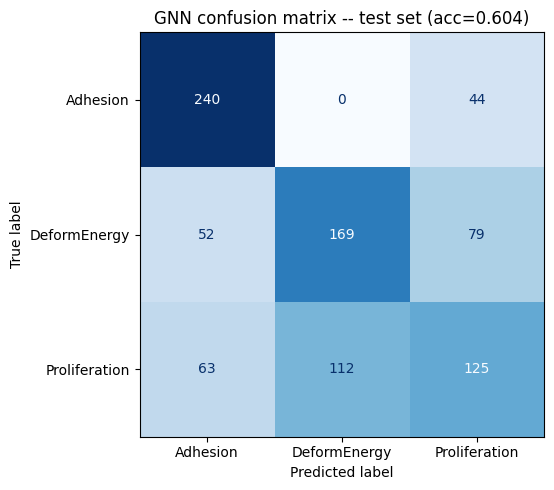

Saved confusion_matrix.png

Per-class accuracy:
  Adhesion: 0.845  (n=284)
  DeformEnergy: 0.563  (n=300)
  Proliferation: 0.417  (n=300)


In [4]:
def tag(graphs, label_attr):
    out = []
    for g in graphs:
        gc = g.clone(); gc.y_task = getattr(g, label_attr); out.append(gc)
    return out

# Load tuned checkpoint
gnn_tuned = GraphSAGEClassifier(in_dim=4, hidden=128, n_classes=3, n_layers=5, dropout=0.0).to(DEVICE)
gnn_tuned.load_state_dict(torch.load(BANK / 'gnn_suite_tuned_ckpt.pt', weights_only=True))
gnn_tuned.eval()

# Collect predictions on test set
all_preds, all_true = [], []
with torch.no_grad():
    for batch in DataLoader(tag(test_s3, 'suite_label_3'), batch_size=64):
        batch = batch.to(DEVICE)
        preds = gnn_tuned(batch.x, batch.edge_index, batch.batch).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_true.extend(batch.y_task.view(-1).cpu().tolist())

test_acc = accuracy_score(all_true, all_preds)
print(f'Tuned GNN test accuracy: {test_acc:.3f}  (chance = 0.333)')

# Confusion matrix
cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=SUITE_NAMES_3)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'GNN confusion matrix -- test set (acc={test_acc:.3f})')
plt.tight_layout()
plt.savefig(BANK / 'confusion_matrix.png', dpi=150)
plt.show()
print('Saved confusion_matrix.png')

# Per-class accuracy
print('\nPer-class accuracy:')
for i, name in enumerate(SUITE_NAMES_3):
    mask = [t == i for t in all_true]
    cls_acc = sum(p == t for p, t in zip(all_preds, all_true) if t == i) / sum(mask)
    print(f'  {name}: {cls_acc:.3f}  (n={sum(mask)})')

## 5. Retraining on all data for the production model

With hyperparameters fixed, combine train + val + test and retrain for 30 epochs
(the epoch count established during tuning). No held-out set is needed here as
the goal is to maximize training signal for deployment on new simulations.

In [5]:
def train_production(all_graphs, label_attr, hidden=128, dropout=0.0, wd=1e-3,
                     lr=5e-4, n_epochs=30, batch_size=64):
    model = GraphSAGEClassifier(hidden=hidden, dropout=dropout, n_layers=5).to(DEVICE)
    opt   = Adam(model.parameters(), lr=lr, weight_decay=wd)
    loader = DataLoader(tag(all_graphs, label_attr), batch_size=batch_size, shuffle=True)

    for epoch in range(n_epochs):
        model.train()
        correct, total = 0, 0
        for batch in loader:
            batch = batch.to(DEVICE); y = batch.y_task.view(-1)
            opt.zero_grad()
            logits = model(batch.x, batch.edge_index, batch.batch)
            loss   = F.cross_entropy(logits, y)
            loss.backward(); opt.step()
            correct += (logits.argmax(1) == y).sum().item(); total += len(y)
        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d} | train acc {correct/total:.3f}')

    return model

print('Training production GNN on all data (train+val+test, 30 epochs) ...')
torch.manual_seed(SEED)
gnn_prod = train_production(all_s3, 'suite_label_3')

torch.save(gnn_prod.state_dict(), BANK / 'gnn_production_ckpt.pt')
print('\nSaved gnn_production_ckpt.pt')

Training production GNN on all data (train+val+test, 30 epochs) ...


  Epoch  10 | train acc 0.743


  Epoch  20 | train acc 0.893


  Epoch  30 | train acc 0.932

Saved gnn_production_ckpt.pt


## 6. Temporal trajectory, running the production model on CycleScale\_2.00\_rep1

Run the production GNN on every snapshot of the fastest proliferating variant
in sequence. We are doing this to show how the model's predicted class probabilities evolve
as the tissue grows over simulated time as the definitive "production use" demonstration.

In [6]:
# Load normalization stats (computed from training data in Checkpoint 1)
feat_stats = torch.load(BANK / 'node_feature_stats.pt', weights_only=False)
feat_mean  = feat_stats['mean'].numpy()
feat_std   = feat_stats['std'].numpy()

def vtu_to_graph(vtu_path):
    """Parse one VTU snapshot into a normalized PyG Data object."""
    mesh = meshio.read(str(vtu_path))
    pts  = mesh.points[:, :2]   # x, y only

    # Collect polygon cells
    polygons = []
    for block in mesh.cells:
        if 'polygon' in block.type or block.type in ('quad', 'triangle', 'hexahedron'):
            for verts in block.data:
                polygons.append([int(v) for v in verts])

    if len(polygons) < 2:
        return None

    # Node features per cell
    rows = []
    for verts in polygons:
        coords = pts[verts]
        x, y   = coords[:, 0], coords[:, 1]
        area   = 0.5 * abs(float(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))))
        perim  = float(sum(np.linalg.norm(coords[(i+1) % len(coords)] - coords[i])
                           for i in range(len(coords))))
        shape  = perim / np.sqrt(max(area, 1e-9))
        rows.append([area, perim, shape, float(len(verts))])
    x_raw = np.array(rows, dtype=np.float32)

    # Normalize with training stats
    x_norm = (x_raw - feat_mean) / (feat_std + 1e-8)

    # Edges: cells sharing >= 2 vertices
    vert_sets = [set(v) for v in polygons]
    edges = []
    for i in range(len(polygons)):
        for j in range(i + 1, len(polygons)):
            if len(vert_sets[i] & vert_sets[j]) >= 2:
                edges += [(i, j), (j, i)]

    ei = torch.tensor(edges, dtype=torch.long).t().contiguous() if edges          else torch.zeros((2, 0), dtype=torch.long)

    return Data(x=torch.tensor(x_norm, dtype=torch.float), edge_index=ei,
                x_raw=torch.tensor(x_raw, dtype=torch.float))


# Discover all time-step directories for CycleScale_2.00_rep1
traj_variant = SIM_ROOT / 'Proliferation' / 'CycleScale_2.00_rep1'
time_dirs = sorted(
    [d for d in traj_variant.iterdir() if d.is_dir() and d.name.startswith('results_from_time_')],
    key=lambda d: int(d.name.split('_')[-1])
)

# Collect VTU files (one per timestep directory)
vtu_files = []
time_indices = []
for d in time_dirs:
    vtu = list(d.glob('results_0.vtu'))
    if vtu:
        vtu_files.append(vtu[0])
        time_indices.append(int(d.name.split('_')[-1]))

print(f'Found {len(vtu_files)} VTU snapshots for CycleScale_2.00_rep1')
print(f'Time range: {time_indices[0]} -> {time_indices[-1]}')

Found 209 VTU snapshots for CycleScale_2.00_rep1
Time range: 0 -> 208


In [7]:
# Run production GNN on each snapshot
gnn_prod.eval()
probs_over_time = []   # shape (n_snapshots, 3)
mean_q_over_time = []
skipped = 0

with torch.no_grad():
    for vtu_path in vtu_files:
        g = vtu_to_graph(vtu_path)
        if g is None:
            skipped += 1
            probs_over_time.append([np.nan, np.nan, np.nan])
            mean_q_over_time.append(np.nan)
            continue
        g = g.to(DEVICE)
        dummy_batch = torch.zeros(g.x.shape[0], dtype=torch.long, device=DEVICE)
        logits = gnn_prod(g.x, g.edge_index, dummy_batch)
        probs  = F.softmax(logits, dim=1).squeeze(0).cpu().numpy()
        probs_over_time.append(probs.tolist())
        mean_q_over_time.append(float(g.x_raw[:, 2].mean()))   # raw shape index

probs_arr  = np.array(probs_over_time)
mean_q_arr = np.array(mean_q_over_time)
times      = np.array(time_indices)
print(f'Processed {len(vtu_files) - skipped}/{len(vtu_files)} snapshots  (skipped {skipped} empty)')

Processed 209/209 snapshots  (skipped 0 empty)


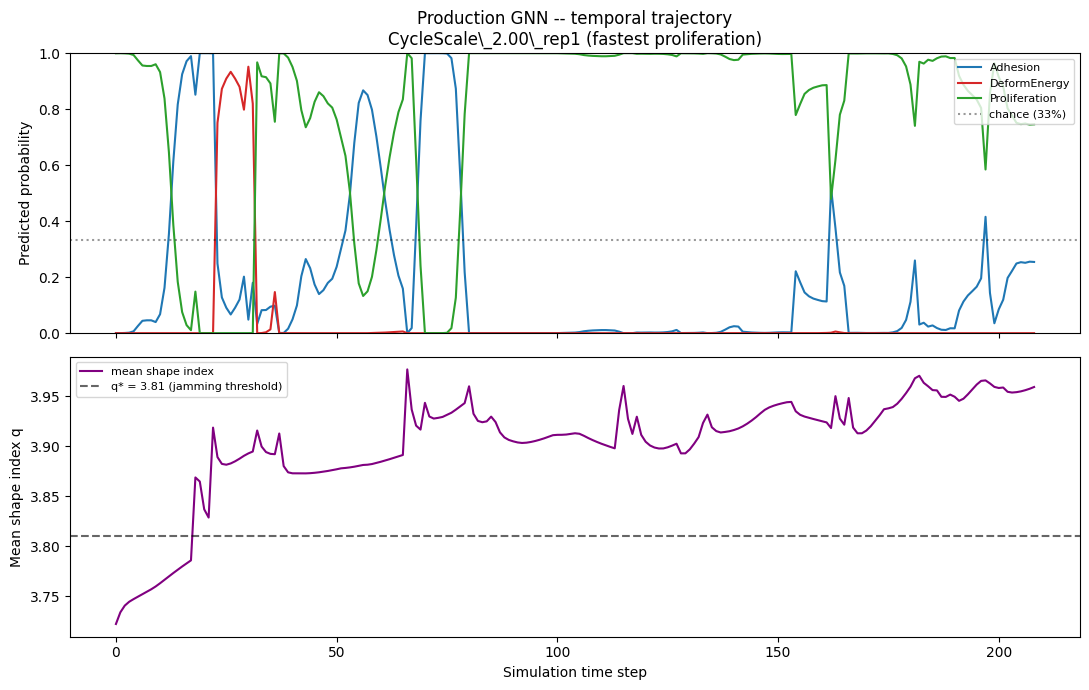

Saved trajectory_plot.png


In [8]:
# Trajectory plot
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
colors = ['#1f77b4', '#d62728', '#2ca02c']

# Top panel: predicted class probabilities over time
for i, (name, color) in enumerate(zip(SUITE_NAMES_3, colors)):
    axes[0].plot(times, probs_arr[:, i], color=color, lw=1.5, label=name)
axes[0].axhline(1/3, color='k', linestyle=':', alpha=0.4, label='chance (33%)')
axes[0].set_ylabel('Predicted probability')
axes[0].set_title('Production GNN -- temporal trajectory\nCycleScale\_2.00\_rep1 (fastest proliferation)')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_ylim(0, 1)

# Bottom panel: mean shape index over time
axes[1].plot(times, mean_q_arr, color='purple', lw=1.5, label='mean shape index')
axes[1].axhline(3.81, color='k', linestyle='--', alpha=0.6, label='q* = 3.81 (jamming threshold)')
axes[1].set_xlabel('Simulation time step')
axes[1].set_ylabel('Mean shape index q')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(BANK / 'trajectory_plot.png', dpi=150)
plt.show()
print('Saved trajectory_plot.png')

## 7. Conclusion & Next Plan for the Final Checkpoint to Wrap-Up the Project

### Three key things were conducted for this specific checkpoint:

**Confusion matrix (on the tuned model for evaluation):**
- Breaks down which suite types the model confuses most
- Provides per-class accuracy, identifying the hardest class to discriminate

**Production model (trained on all 8,305 graphs):**
- Combines train + val + test using the best hyperparameters from Checkpoint 3
- Represents the strongest model for deployment on new simulations
- 30-epoch fixed schedule (epoch count validated during tuning)

**Temporal trajectory:**
- End-to-end pipeline demo: raw `.vtu` files -- graph -- normalized features -- GNN prediction
- Shows how predicted class probabilities evolve over simulated time for a single variant
- Mean shape index overlay connects model predictions to the underlying biology (q* = 3.81)

### Plan for Checkpoint 5 (Final Results) and Final Closeout

1. **Clean up all notebooks** -- consistent formatting, markdown explanations in every section,
   remove debug cells, ensure all notebooks re-run top-to-bottom without errors -> compile into a singular notebook

2. **Organize results folder** -- all saved figures (pca\_plot.png, umap\_plot.png,
   confusion\_matrix.png, trajectory\_plot.png, curves\_.png) in one place

3. **Write final narrative** -- a brief summary cell at the end of each notebook connecting
   results back to the central question: *"Does cell topology encode tissue mechanical state?"*

4. **Cross-checkpoint results table** -- one unified table spanning all checkpoints showing
   how accuracy improved from the first 60-epoch baseline (42%) to the tuned production model

5. **Limitations and future work** -- honest discussion of the val-test gap, the overlapping
   suite topology problem, and what GPU resources + larger datasets would enable

6. **Prepare slides and final Github repo** -- prepare for the final presentation, push all files to Github,
   prepare for the final presentation